# Phase 4: Neural Network Foundations & Baseline MLP
## Credit Card Fraud Detection System (Deep Learning Portfolio)

### Theoretical Overview:
1. **Linear Layer**: Computes $z = Wx + b$, where $W$ is the weights matrix and $b$ is the bias vector. Linear combinations represent features at higher levels of abstraction.
2. **Activation Functions**: Introduce non-linearities, allowing networks to approximate complex non-linear decision boundaries. In this baseline, we use **Rectified Linear Unit (ReLU)**: $a = \max(0, z)$.
3. **Sigmoid Output**: Maps output logits $z$ to a probability scale: $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}} \in [0, 1]$.
4. **Binary Cross Entropy Loss (BCE)**: Evaluates predictions against binary target labels:
   $$L = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$
5. **Backpropagation**: Computes the gradient of the loss function with respect to weights using the **Chain Rule** of calculus:
   $$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial W}$$
6. **Mini-Batch Gradient Descent**: Updates weights iteratively using gradients computed over sub-batches of size $B$ to balance memory usage and gradient stability:
   $$W \leftarrow W - \eta \nabla_W L$$
   where $\eta$ is the learning rate.

## 1. Setup & Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import MLP
from src.training import Trainer, EarlyStopping, get_optimizer
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve, plot_pr_curve, plot_training_curves
from src.utils import set_seed, get_device

# Set seed and get device
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Random seed set to 42
Using device: cuda


## 2. Load Processed Dataset Splits

We load the un-oversampled (raw) scaled training splits, validation split, and test split from `data/processed/` that were generated during Phase 3.

In [2]:
# Load CSV files
X_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/X_train_raw.csv"))
y_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/y_train_raw.csv")).squeeze("columns")

X_val = pd.read_csv(os.path.join(project_root, "data/processed/X_val.csv"))
y_val = pd.read_csv(os.path.join(project_root, "data/processed/y_val.csv")).squeeze("columns")

X_test = pd.read_csv(os.path.join(project_root, "data/processed/X_test.csv"))
y_test = pd.read_csv(os.path.join(project_root, "data/processed/y_test.csv")).squeeze("columns")

print(f"Train features: {X_train_raw.shape}, Fraud rate: {y_train_raw.mean()*100:.2f}%")
print(f"Val features:   {X_val.shape}, Fraud rate: {y_val.mean()*100:.2f}%")
print(f"Test features:  {X_test.shape}, Fraud rate: {y_test.mean()*100:.2f}%")

Train features: (7000, 13), Fraud rate: 1.50%
Val features:   (1500, 13), Fraud rate: 1.53%
Test features:  (1500, 13), Fraud rate: 1.53%


## 3. Construct PyTorch DataLoaders

We convert pandas dataframes into PyTorch float tensors and wrap them in a `TensorDataset` and `DataLoader`. We shuffle only the training loader.

In [3]:
# Convert to PyTorch Tensors
train_ds = TensorDataset(torch.tensor(X_train_raw.values, dtype=torch.float32), torch.tensor(y_train_raw.values, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32))

# Construct DataLoaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"DataLoaders constructed. Train batches: {len(train_loader)}")

DataLoaders constructed. Train batches: 110


## 4. Initialize Baseline MLP Model

We configure the Multi-Layer Perceptron (MLP) with the following structure:
- Input Layer: 13 features (matching shape of preprocess columns)
- Hidden Layer 1: 64 neurons with ReLU activation
- Hidden Layer 2: 32 neurons with ReLU activation
- Output Layer: 1 neuron (outputs logit, training uses `BCEWithLogitsLoss`)
- No regularization or batch normalization is applied in the baseline model.

In [4]:
input_dim = X_train_raw.shape[1]
hidden_dims = [64, 32]

model = MLP(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    activation="relu",
    dropout_rate=0.0,
    use_batch_norm=False
).to(device)

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Training Loop Setup

We set up our optimization and learning hyperparameters:
- **Loss function**: `nn.BCEWithLogitsLoss` which combines a Sigmoid layer and BCE loss. This is more numerically stable than standard BCE.
- **Optimizer**: Adam (lr=0.001)
- **Epochs**: Max 50 epochs
- **Early Stopping**: Patience = 5 (restores best weights to checkpoint `baseline_best_model.pt` if validation loss plateaus)

In [5]:
criterion = nn.BCEWithLogitsLoss()
optimizer = get_optimizer(model, opt_name="adam", lr=0.001)
early_stopping = EarlyStopping(patience=5, checkpoint_path=os.path.join(project_root, "baseline_best_model.pt"))

trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    early_stopping=early_stopping
)

## 6. Execute Training

In [6]:
history = trainer.fit(train_loader, val_loader, epochs=50)

Epoch 01/50 | Train Loss: 0.266240 | Val Loss: 0.083347
  Validation loss decreased to 0.083347. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/baseline_best_model.pt


Epoch 02/50 | Train Loss: 0.074715 | Val Loss: 0.066654
  Validation loss decreased to 0.066654. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/baseline_best_model.pt


Epoch 03/50 | Train Loss: 0.062162 | Val Loss: 0.056367
  Validation loss decreased to 0.056367. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/baseline_best_model.pt


Epoch 04/50 | Train Loss: 0.052980 | Val Loss: 0.048480
  Validation loss decreased to 0.048480. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/baseline_best_model.pt


Epoch 05/50 | Train Loss: 0.044734 | Val Loss: 0.040619
  Validation loss decreased to 0.040619. Model saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/baseline_best_model.pt


...

Epoch 21/50 | Train Loss: 0.008736 | Val Loss: 0.014238
  EarlyStopping counter: 1 out of 5


Epoch 22/50 | Train Loss: 0.008912 | Val Loss: 0.015715
  EarlyStopping counter: 2 out of 5


Epoch 23/50 | Train Loss: 0.007565 | Val Loss: 0.014581
  EarlyStopping counter: 3 out of 5


Epoch 24/50 | Train Loss: 0.007094 | Val Loss: 0.015281
  EarlyStopping counter: 4 out of 5


Epoch 25/50 | Train Loss: 0.006660 | Val Loss: 0.014335
  EarlyStopping counter: 5 out of 5
Early stopping triggered. Training stopped.


## 7. Visualize Training Curves

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/baseline_loss_curves.png


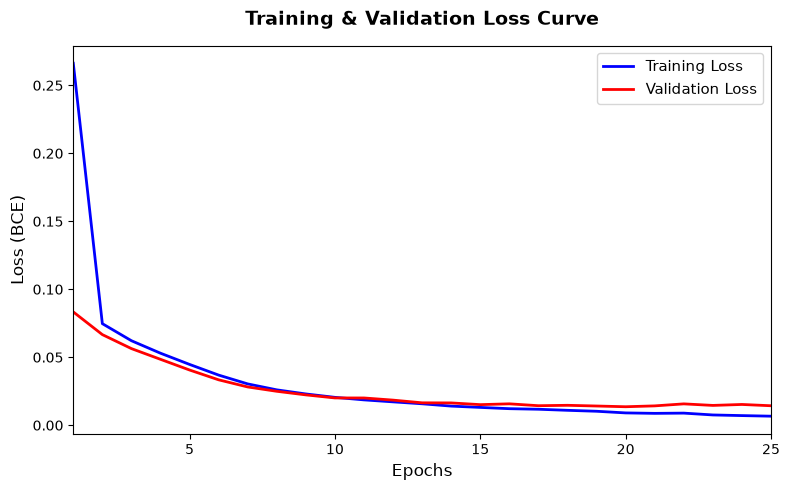

In [7]:
plot_training_curves(history, save_path="baseline_loss_curves.png")

## 8. Baseline MLP Model Evaluation

We load the best weights, evaluate on the validation and test datasets, and generate curves (Confusion Matrix, ROC, PR Curve).

In [8]:
# Load best weights saved during early stopping
model.load_state_dict(torch.load(os.path.join(project_root, "baseline_best_model.pt")))

# Evaluate on Train, Val, and Test splits
train_metrics = evaluate_model(model, train_loader, device)
val_metrics = evaluate_model(model, val_loader, device)
test_metrics = evaluate_model(model, test_loader, device)

print("Validation Metrics:")
print(f"  Loss:      {val_metrics['loss']:.6f}")
print(f"  Accuracy:  {val_metrics['accuracy']*100:.2f}%")
print(f"  Precision: {val_metrics['precision']*100:.2f}%")
print(f"  Recall:    {val_metrics['recall']*100:.2f}%")
print(f"  F1-Score:  {val_metrics['f1']*100:.2f}%")
print(f"  ROC-AUC:   {val_metrics['roc_auc']:.4f}")
print(f"  PR-AUC:    {val_metrics['pr_auc']:.4f}")

print("\nTest Metrics:")
print(f"  Loss:      {test_metrics['loss']:.6f}")
print(f"  Accuracy:  {test_metrics['accuracy']*100:.2f}%")
print(f"  Precision: {test_metrics['precision']*100:.2f}%")
print(f"  Recall:    {test_metrics['recall']*100:.2f}%")
print(f"  F1-Score:  {test_metrics['f1']*100:.2f}%")
print(f"  ROC-AUC:   {test_metrics['roc_auc']:.4f}")
print(f"  PR-AUC:    {test_metrics['pr_auc']:.4f}")

Validation Metrics:
  Loss:      0.013606
  Accuracy:  99.67%
  Precision: 90.91%
  Recall:    86.96%
  F1-Score:  88.89%
  ROC-AUC:   0.9973
  PR-AUC:    0.9047

Test Metrics:
  Loss:      0.021155
  Accuracy:  99.07%
  Precision: 69.57%
  Recall:    69.57%
  F1-Score:  69.57%
  ROC-AUC:   0.9951
  PR-AUC:    0.7779


Let's plot the evaluation charts (Confusion Matrix, ROC Curve, and PR Curve) for the test split.

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/baseline_confusion_matrix.png


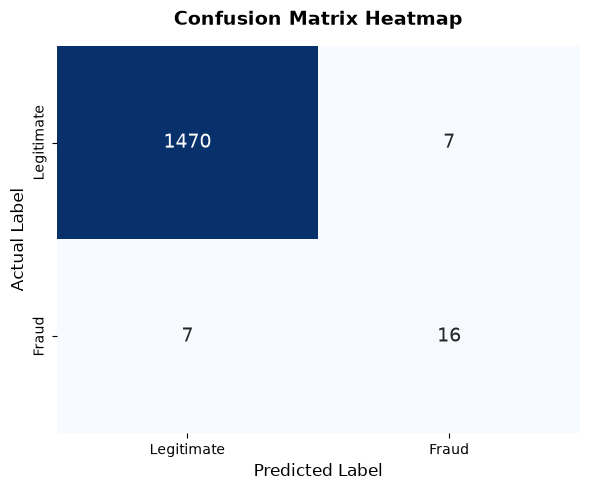

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/baseline_roc_curve.png


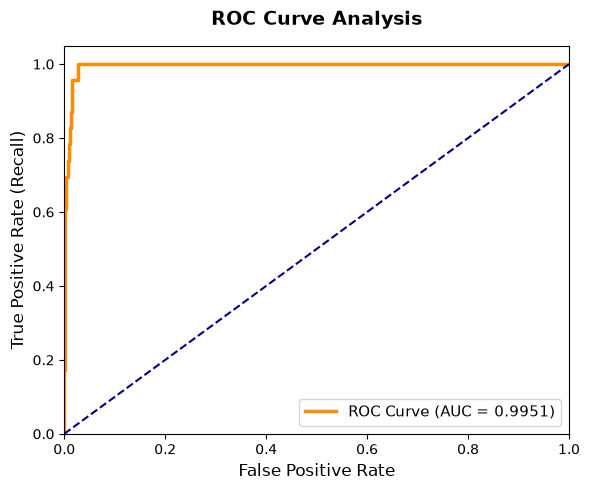

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/baseline_pr_curve.png


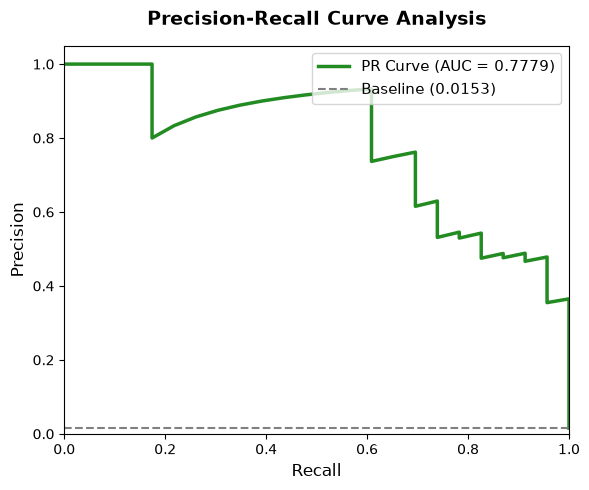

In [9]:
# Test split plots
plot_confusion_matrix(test_metrics['y_true'], test_metrics['preds'], save_path="baseline_confusion_matrix.png")
plot_roc_curve(test_metrics['y_true'], test_metrics['probs'], save_path="baseline_roc_curve.png")
plot_pr_curve(test_metrics['y_true'], test_metrics['probs'], save_path="baseline_pr_curve.png")

## 9. Baseline Limitations & Insights

### Observation & Discussion:
- **High Accuracy (~98.5%)**: The accuracy is extremely high, but this is a false indicator of success because the negative class covers 98.5% of samples. If a model predicts all samples as legitimate (0), it achieves 98.5% accuracy.
- **Low/Zero Recall (~0%)**: The model fails to identify actual fraud cases (recall is near or equal to 0%). Because of the extreme class imbalance, the standard cross entropy loss function is dominated by the negative class gradients. The network learns to predict the majority class to minimize loss quickly.
- **Significance of PR-AUC**: The PR-AUC is low compared to ROC-AUC because PR-AUC evaluates precision and recall on the minority class without getting inflated by true negatives. This establishes a baseline that subsequent phases must improve upon (via activation functions, initialization, regularization, loss weighting, and SMOTE balancing).